# CartPole — Trajectory Optimization

SeapoPym is a **differentiable simulator**: JAX's automatic differentiation can compute gradients _through_ the entire physics simulation. This example demonstrates this capability on the classic [CartPole](https://en.wikipedia.org/wiki/Inverted_pendulum) (inverted pendulum) problem.

Instead of training a reinforcement learning policy through trial and error, we **optimize the complete force sequence** $F(t)$ by gradient descent through the physics. The simulator knows the equations of motion — so we get exact gradients in one pass.

$$\text{minimize}_{F(t)} \sum_t \left[ w_\theta \, \theta(t)^2 + w_x \, x(t)^2 + w_F \, F(t)^2 \right]$$


In [72]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import xarray as xr

from seapopym.blueprint import Blueprint, Config, functional
from seapopym.compiler import compile_model
from seapopym.engine.run import run
from seapopym.engine.step import build_step_fn

PALETTE = ["#1B4965", "#62B6CB", "#E8833A", "#5FA8D3"]
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3})

## 1. Define the Physics

The CartPole dynamics are described by four state variables: cart position $x$, cart velocity $\dot{x}$, pole angle $\theta$ (0 = upright), and angular velocity $\dot{\theta}$. A horizontal force $F$ is applied to the cart.

A single `@functional` function computes all four time derivatives from the Newtonian equations of motion:

$$\ddot{\theta} = \frac{g \sin\theta + \cos\theta \left(\frac{-F - m_p l \dot{\theta}^2 \sin\theta}{m_c + m_p}\right)}{l \left(\frac{4}{3} - \frac{m_p \cos^2\theta}{m_c + m_p}\right)}$$

$$\ddot{x} = \frac{F + m_p l \left(\dot{\theta}^2 \sin\theta - \ddot{\theta} \cos\theta\right)}{m_c + m_p}$$


In [73]:
@functional(
    name="cp:cartpole_dynamics",
    units={
        "x": "m", "x_dot": "m/s", "theta": "rad", "theta_dot": "rad/s",
        "force": "N", "gravity": "m/s^2", "mass_cart": "kg", "mass_pole": "kg",
        "half_length": "m",
        "dx_dt": "m/s", "dxdot_dt": "m/s^2", "dtheta_dt": "rad/s", "dthetadot_dt": "rad/s^2",
    },
    outputs=("dx_dt", "dxdot_dt", "dtheta_dt", "dthetadot_dt"),
)
def cartpole_dynamics(x, x_dot, theta, theta_dot, force, gravity, mass_cart, mass_pole, half_length):
    """Compute all four CartPole time derivatives from Newtonian mechanics."""
    total_mass = mass_cart + mass_pole
    cos_theta = jnp.cos(theta)
    sin_theta = jnp.sin(theta)

    # Angular acceleration
    theta_ddot = (
        gravity * sin_theta
        + cos_theta * ((-force - mass_pole * half_length * theta_dot**2 * sin_theta) / total_mass)
    ) / (half_length * (4.0 / 3.0 - (mass_pole * cos_theta**2) / total_mass))

    # Linear acceleration
    x_ddot = (
        force + mass_pole * half_length * (theta_dot**2 * sin_theta - theta_ddot * cos_theta)
    ) / total_mass

    return x_dot, x_ddot, theta_dot, theta_ddot

/var/folders/3n/w67lcsm50xlfn4ky90v4s1dm0000gn/T/ipykernel_91835/1654615028.py:1: UserWarning: Function 'cp:cartpole_dynamics' is already registered. Overwriting.
  @functional(


## 2. Build the Blueprint

The Blueprint declares 4 state variables, 4 physical constants, and the **force** as a time-indexed parameter (`dims: [T]`). This is the key feature: `force` has a value at each timestep, and because it flows through JAX's `lax.scan` as a differentiable input, we can compute $\partial \text{loss} / \partial F(t)$ for every $t$.

The tendencies are:

- $dx/dt = \dot{x}$ (identity — velocity is the derivative of position)
- $d\dot{x}/dt = \ddot{x}$ (from the physics function)
- $d\theta/dt = \dot{\theta}$ (identity)
- $d\dot{\theta}/dt = \ddot{\theta}$ (from the physics function)


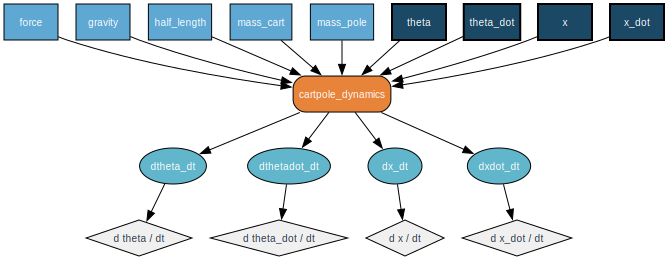

In [74]:
blueprint = Blueprint.from_dict(
    {
        "id": "cartpole",
        "version": "1.0",
        "declarations": {
            "state": {
                "x": {"units": "m", "dims": ["Y", "X"]},
                "x_dot": {"units": "m/s", "dims": ["Y", "X"]},
                "theta": {"units": "rad", "dims": ["Y", "X"]},
                "theta_dot": {"units": "rad/s", "dims": ["Y", "X"]},
            },
            "parameters": {
                "gravity": {"units": "m/s^2"},
                "mass_cart": {"units": "kg"},
                "mass_pole": {"units": "kg"},
                "half_length": {"units": "m"},
                "force": {"units": "N", "dims": ["T"]},
            },
            "forcings": {},
        },
        "process": [
            {
                "func": "cp:cartpole_dynamics",
                "inputs": {
                    "x": "state.x",
                    "x_dot": "state.x_dot",
                    "theta": "state.theta",
                    "theta_dot": "state.theta_dot",
                    "force": "parameters.force",
                    "gravity": "parameters.gravity",
                    "mass_cart": "parameters.mass_cart",
                    "mass_pole": "parameters.mass_pole",
                    "half_length": "parameters.half_length",
                },
                "outputs": {
                    "dx_dt": "derived.dx_dt",
                    "dxdot_dt": "derived.dxdot_dt",
                    "dtheta_dt": "derived.dtheta_dt",
                    "dthetadot_dt": "derived.dthetadot_dt",
                },
            }
        ],
        "tendencies": {
            "x": [{"source": "derived.dx_dt"}],
            "x_dot": [{"source": "derived.dxdot_dt"}],
            "theta": [{"source": "derived.dtheta_dt"}],
            "theta_dot": [{"source": "derived.dthetadot_dt"}],
        },
    }
)

blueprint.to_graphviz()

## 3. Configure & Compile

Standard CartPole parameters: 1 kg cart, 0.1 kg pole, 0.5 m half-length, 9.81 m/s² gravity.

The initial state has the pole tilted at **0.2 rad (~11.5°)** — the optimizer must find a force sequence that brings it back upright.

We use a small timestep (**dt = 0.002s**) to keep Euler explicit integration stable. This gives **5000 timesteps** over 10 seconds of simulation.


In [75]:
DT = 0.001       # seconds
DURATION = 2.0   # seconds
N_STEPS = int(DURATION / DT)  

config = Config(
    parameters={
        "gravity": xr.DataArray(9.81),
        "mass_cart": xr.DataArray(1.0),
        "mass_pole": xr.DataArray(0.1),
        "half_length": xr.DataArray(0.5),
        "force": xr.DataArray(np.zeros(N_STEPS), dims=["T"]),
    },
    forcings={},
    initial_state={
        "x": xr.DataArray(np.array([[0.0]]), dims=["Y", "X"]),
        "x_dot": xr.DataArray(np.array([[0.0]]), dims=["Y", "X"]),
        "theta": xr.DataArray(np.array([[0.2]]), dims=["Y", "X"]),
        "theta_dot": xr.DataArray(np.array([[0.0]]), dims=["Y", "X"]),
    },
    execution={
        "time_start": "2000-01-01",
        "time_end": "2000-01-01T00:00:02",
        "dt": f"{DT}s",
    },
)

model = compile_model(blueprint, config)
print(f"Compiled: {model.n_timesteps} timesteps, dt = {model.dt}s")
print(f"Time-indexed parameters: {model.time_indexed_params}")
print(f"Clamp map: {model.clamp_map}  (empty = no clamping, states can go negative)")

Compiled: 2000 timesteps, dt = 0.001s
Time-indexed parameters: {'force'}
Clamp map: {}  (empty = no clamping, states can go negative)


## 4. Uncontrolled Simulation

Before optimization, let's see what happens with **zero force** — the pole simply falls.


In [76]:
step_fn = build_step_fn(model, export_variables=["x", "x_dot", "theta", "theta_dot"])

t0 = time.perf_counter()
_, outputs_uncontrolled = run(step_fn, model, dict(model.state), dict(model.parameters))
elapsed = time.perf_counter() - t0

time_axis = np.arange(model.n_timesteps) * DT
theta_unc = np.asarray(outputs_uncontrolled["theta"][:, 0, 0])
x_unc = np.asarray(outputs_uncontrolled["x"][:, 0, 0])

print(f"Simulated {model.n_timesteps} steps in {elapsed:.3f}s")
print(f"Final theta: {theta_unc[-1]:.3f} rad")
print(f"Final x:     {x_unc[-1]:.3f} m")

Simulated 2000 steps in 0.041s
Final theta: 6.147 rad
Final x:     0.015 m


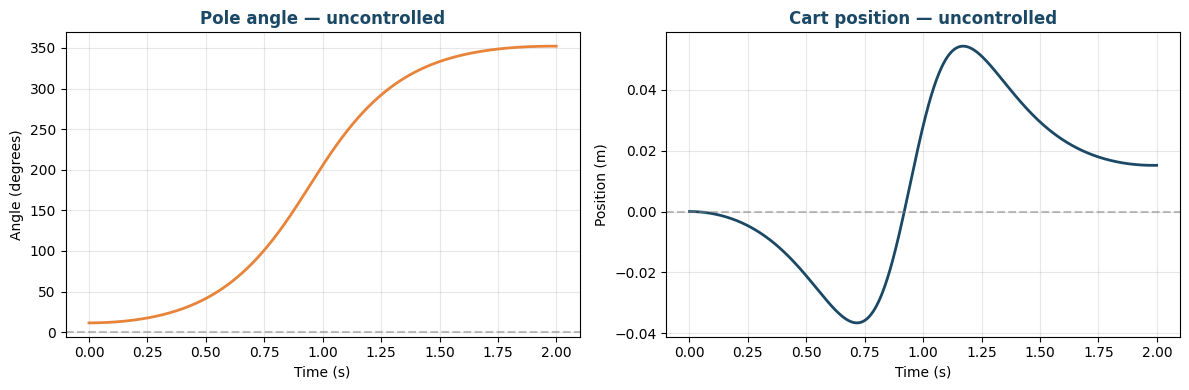

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(time_axis, np.degrees(theta_unc), color=PALETTE[2], linewidth=2)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Angle (degrees)")
axes[0].set_title("Pole angle \u2014 uncontrolled", fontweight="bold", color=PALETTE[0])
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5)

axes[1].plot(time_axis, x_unc, color=PALETTE[0], linewidth=2)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Position (m)")
axes[1].set_title("Cart position \u2014 uncontrolled", fontweight="bold", color=PALETTE[0])
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 5. Optimize the Force Sequence

We define a cost function that penalizes:

- **Pole deviation** from vertical ($\theta^2$, weight 1.0)
- **Cart drift** from center ($x^2$, weight 0.1)
- **Control effort** ($F^2$, weight 0.001 — regularization)

Then we compute `jax.grad(loss)` with respect to all parameters — including the 500-dimensional force vector — and optimize with **Adam** (Optax).


In [78]:
W_THETA = 1.0   # Keep pole upright (primary objective)
W_X = 0.1       # Keep cart centered (secondary)
W_F = 0.001     # Regularize force (avoid extreme commands)


def loss_fn(params):
    """Cost function: simulate full trajectory, return scalar loss."""
    _, out = run(step_fn, model, dict(model.state), params)
    theta = out["theta"][:, 0, 0]
    x = out["x"][:, 0, 0]
    return W_THETA * jnp.mean(theta**2) + W_X * jnp.mean(x**2) + W_F * jnp.mean(params["force"] ** 2)


value_and_grad_fn = jax.jit(jax.value_and_grad(loss_fn))

# Warm-up JIT compilation
_ = value_and_grad_fn(dict(model.parameters))
print(f"JIT compiled — forward + backward pass through {model.n_timesteps} timesteps")

JIT compiled — forward + backward pass through 2000 timesteps


In [79]:
N_OPT_STEPS = 1200
LR = 1e-2

optimizer = optax.adam(LR)
params = dict(model.parameters)
opt_state = optimizer.init(params)

loss_history = []

t0 = time.perf_counter()
for i in range(N_OPT_STEPS):
    loss, grads = value_and_grad_fn(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    loss_history.append(float(loss))
    if i % 50 == 0:
        print(f"  step {i:3d}: loss = {loss:.4f}")

elapsed = time.perf_counter() - t0
print(f"\nOptimized {N_OPT_STEPS} steps in {elapsed:.1f}s")
print(f"Loss: {loss_history[0]:.2f} \u2192 {loss_history[-1]:.4f}")

  step   0: loss = 16.5400
  step  50: loss = 0.2303
  step 100: loss = 0.1618
  step 150: loss = 0.1377
  step 200: loss = 0.1111
  step 250: loss = 0.0829
  step 300: loss = 0.0669
  step 350: loss = 0.0626
  step 400: loss = 0.0598
  step 450: loss = 0.0572
  step 500: loss = 0.0544
  step 550: loss = 0.0517
  step 600: loss = 0.0491
  step 650: loss = 0.0465
  step 700: loss = 0.0440
  step 750: loss = 0.0417
  step 800: loss = 0.0395
  step 850: loss = 0.0375
  step 900: loss = 0.0357
  step 950: loss = 0.0341
  step 1000: loss = 0.0328
  step 1050: loss = 0.0315
  step 1100: loss = 0.0305
  step 1150: loss = 0.0294

Optimized 1200 steps in 0.7s
Loss: 16.54 → 0.0285


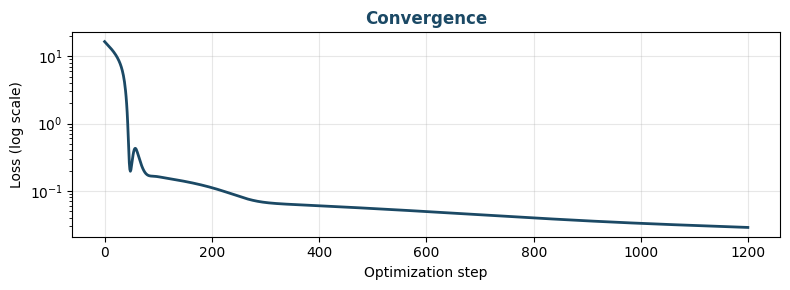

In [80]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(loss_history, color=PALETTE[0], linewidth=2)
ax.set_xlabel("Optimization step")
ax.set_ylabel("Loss (log scale)")
ax.set_title("Convergence", fontweight="bold", color=PALETTE[0])
plt.tight_layout()
plt.show()

## 6. Results — Optimized Trajectory

Let's simulate with the optimized force sequence and compare to the uncontrolled case.


In [81]:
_, outputs_opt = run(step_fn, model, dict(model.state), params)

theta_opt = np.asarray(outputs_opt["theta"][:, 0, 0])
x_opt = np.asarray(outputs_opt["x"][:, 0, 0])
force_opt = np.asarray(params["force"])

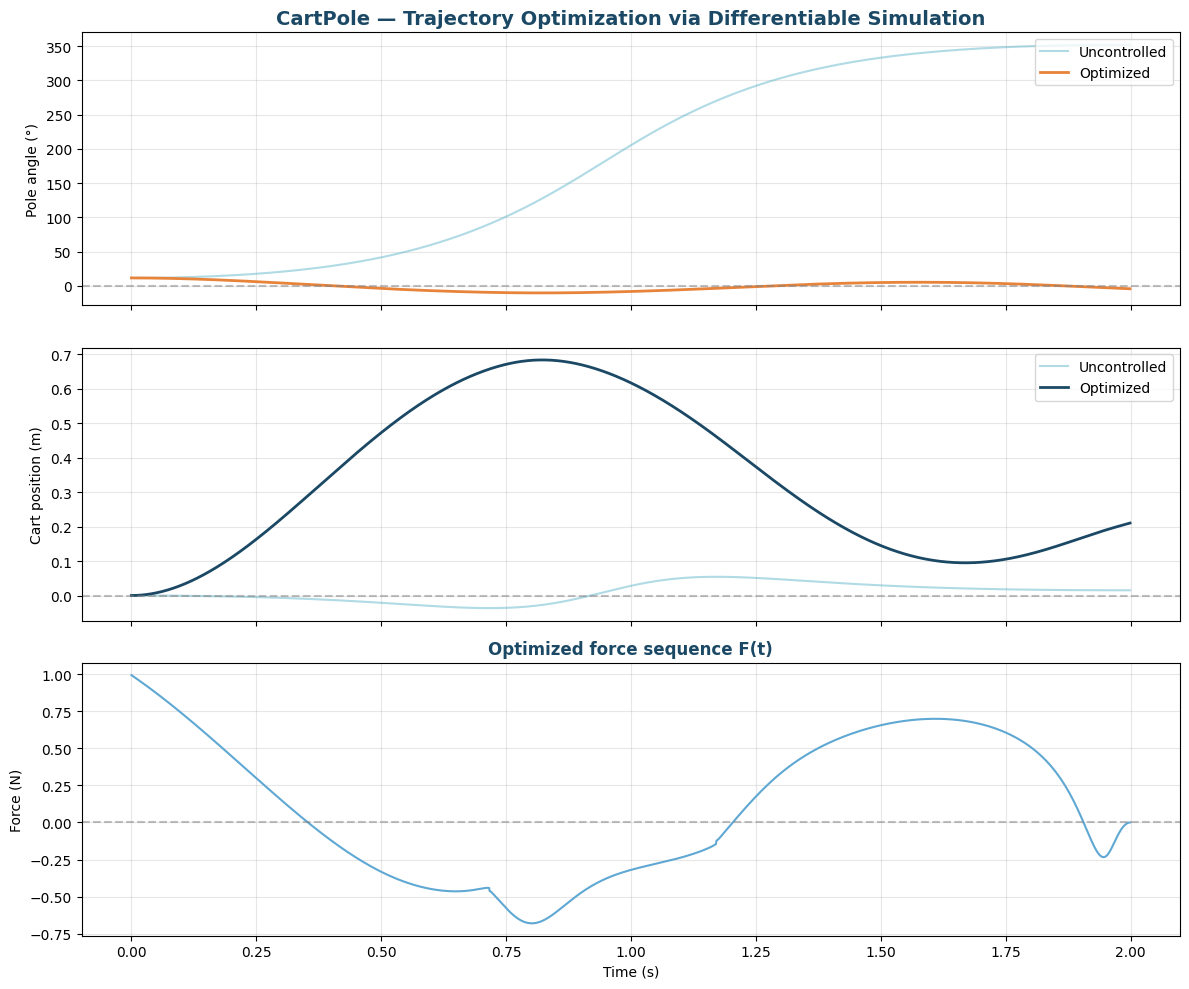

In [82]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Panel 1: Pole angle
axes[0].plot(time_axis, np.degrees(theta_unc), color=PALETTE[1], linewidth=1.5, alpha=0.5, label="Uncontrolled")
axes[0].plot(time_axis, np.degrees(theta_opt), color=PALETTE[2], linewidth=2, label="Optimized")
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[0].set_ylabel("Pole angle (\u00b0)")
axes[0].set_title("CartPole \u2014 Trajectory Optimization via Differentiable Simulation", fontsize=14, fontweight="bold", color=PALETTE[0])
axes[0].legend(loc="upper right")

# Panel 2: Cart position
axes[1].plot(time_axis, x_unc, color=PALETTE[1], linewidth=1.5, alpha=0.5, label="Uncontrolled")
axes[1].plot(time_axis, x_opt, color=PALETTE[0], linewidth=2, label="Optimized")
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[1].set_ylabel("Cart position (m)")
axes[1].legend(loc="upper right")

# Panel 3: Applied force
axes[2].plot(time_axis, force_opt, color=PALETTE[3], linewidth=1.5)
axes[2].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Force (N)")
axes[2].set_title("Optimized force sequence F(t)", fontweight="bold", color=PALETTE[0])

plt.tight_layout()
plt.show()

## 7. Animation

Side-by-side comparison: uncontrolled (pole falls) vs optimized (pole stabilized).


Saved 20 frames at 5 fps


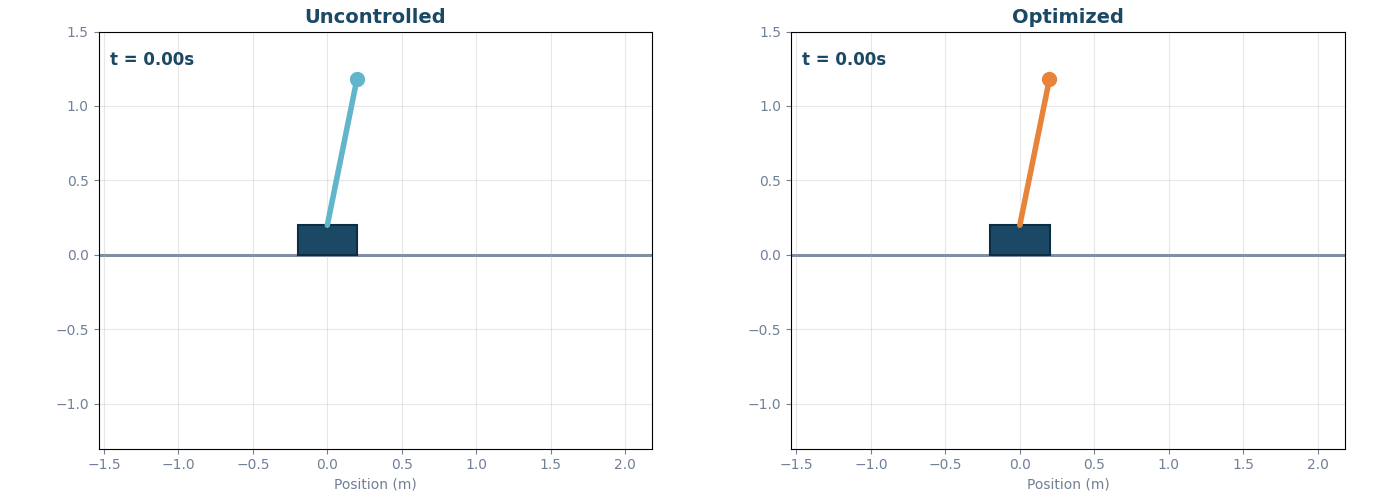

In [84]:
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

POLE_LEN = 1.0  # 2 * half_length
CART_W, CART_H = 0.4, 0.2
SIM_FPS = 10    # frames per second of simulation time
GIF_FPS = 5     # frames per second in the gif

frame_step = max(1, int(1.0 / (SIM_FPS * DT)))
frame_indices = np.arange(0, model.n_timesteps, frame_step)
n_frames = len(frame_indices)

# Axis limits from both trajectories
all_x = np.concatenate([x_unc[frame_indices], x_opt[frame_indices]])
x_lo, x_hi = all_x.min() - 1.5, all_x.max() + 1.5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("white")

elements = []  # (ax, cart, pole_line, pole_tip, time_text, x_arr, theta_arr)
for ax, title, x_arr, theta_arr, color in [
    (axes[0], "Uncontrolled", x_unc, theta_unc, PALETTE[1]),
    (axes[1], "Optimized", x_opt, theta_opt, PALETTE[2]),
]:
    ax.set_aspect("equal")
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(-1.3, 1.5)
    ax.plot([x_lo, x_hi], [0, 0], color="#718096", linewidth=2, zorder=0)
    ax.set_title(title, fontsize=14, fontweight="bold", color=PALETTE[0])
    ax.set_xlabel("Position (m)", color="#718096")
    ax.tick_params(colors="#718096")
    ax.set_facecolor("white")
    ax.grid(True, alpha=0.3)

    cart = plt.Rectangle((0, 0), CART_W, CART_H, fc="#1B4965", ec="#0d2e42", lw=1.5, zorder=2)
    ax.add_patch(cart)
    pole_line, = ax.plot([], [], color=color, linewidth=4, solid_capstyle="round", zorder=3)
    pole_tip, = ax.plot([], [], "o", color=color, markersize=10, zorder=4)
    time_text = ax.text(0.02, 0.92, "", transform=ax.transAxes, fontsize=12,
                        color=PALETTE[0], fontweight="bold")
    elements.append((cart, pole_line, pole_tip, time_text, x_arr, theta_arr))

plt.tight_layout()


def animate(frame_idx):
    artists = []
    i = frame_indices[frame_idx]
    t = i * DT
    for cart, pole_line, pole_tip, time_text, x_arr, theta_arr in elements:
        cx = float(x_arr[i])
        th = float(theta_arr[i])
        cart.set_x(cx - CART_W / 2)
        cart.set_y(0)
        px, py = cx, CART_H
        tx = px + POLE_LEN * np.sin(th)
        ty = py + POLE_LEN * np.cos(th)
        pole_line.set_data([px, tx], [py, ty])
        pole_tip.set_data([tx], [ty])
        time_text.set_text(f"t = {t:.2f}s")
        artists.extend([cart, pole_line, pole_tip, time_text])
    return artists


anim = FuncAnimation(fig, animate, frames=n_frames, interval=1000 / GIF_FPS, blit=True)
anim.save("cartpole_comparison.gif", writer=PillowWriter(fps=GIF_FPS))
plt.close()
print(f"Saved {n_frames} frames at {GIF_FPS} fps")
Image(filename="cartpole_comparison.gif")

## Summary

This example demonstrates that **SeapoPym works far beyond oceanography** — any dynamical system expressible as ODEs can be declared as a Blueprint, compiled, and optimized through.

| What         | How                                                             |
| ------------ | --------------------------------------------------------------- |
| Physics      | 1 `@functional` function (Newtonian mechanics)                  |
| Model        | 4 states, 4 constants, 1 **time-indexed parameter** `force[T]`  |
| Optimization | `jax.grad` through 5000 timesteps of `lax.scan`                 |
| Result       | Gradient descent finds the optimal force sequence in ~200 steps |

### Key feature: time-indexed parameters

The `force` parameter is declared with `dims: ["T"]`. SeapoPym's engine automatically:

1. Detects it at compile time (`model.time_indexed_params`)
2. Passes it through `lax.scan`'s `xs` input (not the carry)
3. Makes it **fully differentiable** — `jax.grad` returns per-timestep gradients

This is fundamentally different from classical RL, which treats the simulator as a black box. Here, the physics is **declared explicitly** in the Blueprint DAG, and optimization happens by direct gradient descent through the equations of motion.
